# Notebook - Find best Drug compound for `Ebola virus (Ebola + Zaire Ebola)`

### Train an ML model by combining `PubChem + chEMBL` data 

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [4]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [5]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load
from PIL import Image
import pickle
import gc
from joblib import Parallel, delayed
from copy import deepcopy


sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [6]:
%config InlineBackend.figure_format = 'retina'

## 1. Training Data preparation

In [74]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "combinedEbolaVirus_bestMACAW_allDB/")
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
ARTresultsDir = '/users/sghosh6/DTRA_project/MACAW/DTRA_ART/ART_CommandLine/Ebola_allDB'
os.makedirs(saveDir, exist_ok=True)

### 1.1 Read data for Ebola virus from ChEMBL

In [9]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')
EbolavirusData_chEMBL_uM = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['Virus'] == 'Ebola']
EbolavirusData_chEMBL_uM = EbolavirusData_chEMBL_uM.rename(columns={'Virus': 'strain'})
EbolavirusData_chEMBL_uM

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,macaw_5,macaw_6,macaw_7,macaw_8,macaw_9,macaw_10,macaw_11,macaw_12,macaw_13,macaw_14
13073,41083,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,...,0.006125,0.032325,-0.005514,0.014946,-0.068306,0.002261,0.028301,-0.037584,-0.015015,0.067482
13074,41086,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.27,Small molecule,320.0,nM,...,0.019910,0.023265,0.001273,0.028700,-0.015329,0.033491,0.007513,-0.009884,0.003394,0.009185
13075,41087,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.73,Unknown,1880.0,nM,...,0.011136,0.018077,0.011553,-0.007442,-0.022893,-0.040621,-0.033679,-0.006937,0.020518,0.003108
13076,41088,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.73,Unknown,2490.0,nM,...,0.017981,0.016326,0.010736,0.001978,-0.026404,-0.036595,-0.028036,-0.003515,0.011954,0.003062
13077,41089,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.00,Unknown,50000.0,nM,...,-0.015402,0.018391,0.067576,-0.067339,0.014091,0.008512,0.019060,-0.001695,-0.087371,-0.015105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13794,42032,CHEMBL5591747,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,C20H36N2O2,NUMKCFVODGNSTL-XKGZKEIXSA-N,InChI=1S/C20H36N2O2/c1-5-21-11-13-22(14-12-21)...,336.52,NaN,5300.0,nM,...,-0.017011,-0.003469,0.012631,0.031284,-0.036755,-0.003303,0.017838,0.014108,0.031967,-0.012162
13795,42033,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,C17H30N2O2,BGOGHLRTERBUFT-LXTVHRRPSA-N,"InChI=1S/C17H30N2O2/c1-12-14-9-13(17(14,2)3)10...",294.44,NaN,34000.0,nM,...,-0.015695,-0.026904,0.015487,0.042253,-0.028495,0.009381,0.025242,0.045584,0.011528,-0.040162
13796,42034,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.10,Small molecule,61880.0,nM,...,0.022080,0.055469,0.026804,-0.087711,-0.051786,0.078345,0.320266,0.007654,0.002948,0.226002
13797,42035,CHEMBL5595942,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCN1CCOCC1,C17H29NO3,MBWOXPVSSAKRDX-JLJPHGGASA-N,"InChI=1S/C17H29NO3/c1-16(2)13-4-6-17(3,12-13)1...",295.42,NaN,34000.0,nM,...,-0.016738,0.008345,0.019812,0.036986,-0.054005,-0.014964,0.007423,0.001470,0.034172,-0.006628


### Read data for Zaire Ebola

In [10]:
EbolavirusAllStrainData_chEMBL_uM = pd.read_csv(modelBuildingDataDir + 'EbolaAllStrainsData_chEMBL_uM.csv')
EbolavirusAllStrainData_chEMBL_uM

,Unnamed: 0,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,...,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM,pPotency,pPotencyMid
0,2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,...,0.70,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,100.00,NaN,4.000000
1,5,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.27,Small molecule,320.0,...,0.56,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,0.32,NaN,6.494850
2,6,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.73,Unknown,1880.0,...,0.12,46.0,5.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,1.88,5.725842,5.725842
3,7,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.73,Unknown,2490.0,...,0.12,50.0,5.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,2.49,5.603801,5.603801
4,8,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.00,Unknown,50000.0,...,0.04,59.0,3.0,3.0,CHEMBL4434621,Ebolavirus,Ebolavirus,50.00,NaN,4.301030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,...,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,6.283997,6.283997
1108,1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,...,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,6.283997,6.283997
1109,1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,...,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,5.721246,5.721246
1110,1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,...,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,5.721246,5.721246


In [11]:
ZaireEbolavirusData_chEMBL_uM = EbolavirusAllStrainData_chEMBL_uM[EbolavirusAllStrainData_chEMBL_uM['strain'] == 'ZaireEbola']
ZaireEbolavirusData_chEMBL_uM

,Unnamed: 0,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,...,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM,pPotency,pPotencyMid
977,1262,ZaireEbola,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.10,Small molecule,67000.0,...,0.57,11.0,1.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,67.00,4.173925,4.173925
978,1263,ZaireEbola,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.10,Small molecule,67000.0,...,0.57,11.0,1.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,67.00,4.173925,4.173925
979,1264,ZaireEbola,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.10,Small molecule,24000.0,...,0.57,11.0,1.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,24.00,4.619789,4.619789
980,1265,ZaireEbola,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.10,Small molecule,24000.0,...,0.57,11.0,1.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,24.00,4.619789,4.619789
981,1266,ZaireEbola,CHEMBL5611967,O=C(Nc1cccc(Cl)c1)c1ccc(-c2cccc(OC3CCNCC3)c2)s1,C22H21ClN2O2S,ADGQEJABTJNTPK-UHFFFAOYSA-N,InChI=1S/C22H21ClN2O2S/c23-16-4-2-5-17(14-16)2...,412.94,NaN,1860.0,...,0.59,28.0,3.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.86,5.730487,5.730487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,...,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,6.283997,6.283997
1108,1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,...,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,6.283997,6.283997
1109,1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,...,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,5.721246,5.721246
1110,1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,...,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,5.721246,5.721246


### Filter columns and keeping only data for Ebola virus (Ebola + Zaire)

In [12]:
combinedEbolaVirusData_chEMBL = pd.concat([EbolavirusData_chEMBL_uM, ZaireEbolavirusData_chEMBL_uM], axis=0)
combinedEbolaVirusData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,macaw_5,macaw_6,macaw_7,macaw_8,macaw_9,macaw_10,macaw_11,macaw_12,macaw_13,macaw_14
13073,41083,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,...,0.006125,0.032325,-0.005514,0.014946,-0.068306,0.002261,0.028301,-0.037584,-0.015015,0.067482
13074,41086,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.27,Small molecule,320.0,nM,...,0.019910,0.023265,0.001273,0.028700,-0.015329,0.033491,0.007513,-0.009884,0.003394,0.009185
13075,41087,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.73,Unknown,1880.0,nM,...,0.011136,0.018077,0.011553,-0.007442,-0.022893,-0.040621,-0.033679,-0.006937,0.020518,0.003108
13076,41088,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.73,Unknown,2490.0,nM,...,0.017981,0.016326,0.010736,0.001978,-0.026404,-0.036595,-0.028036,-0.003515,0.011954,0.003062
13077,41089,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.00,Unknown,50000.0,nM,...,-0.015402,0.018391,0.067576,-0.067339,0.014091,0.008512,0.019060,-0.001695,-0.087371,-0.015105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1108,1421,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,nM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1109,1422,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1110,1423,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,nM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Remove `Remdesivir` from training set

In [13]:
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Remdesivir_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
combinedEbolaVirusData_chEMBL["canonical_smiles"] = (
    combinedEbolaVirusData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Split into two dataframes
combinedEbolaVirusData_chEMBL_wRemdesivir = combinedEbolaVirusData_chEMBL[
    combinedEbolaVirusData_chEMBL["canonical_smiles"] == remCan
].copy()

combinedEbolaVirusData_chEMBL_clean = combinedEbolaVirusData_chEMBL[
    combinedEbolaVirusData_chEMBL["canonical_smiles"] != remCan
].copy()

print(f"Original shape: {len(combinedEbolaVirusData_chEMBL)}")
print(f"Remdesivir only: {len(combinedEbolaVirusData_chEMBL_wRemdesivir)}")
print(f"Without Remdesivir: {len(combinedEbolaVirusData_chEMBL_clean)}")

combinedEbolaVirusData_chEMBL = combinedEbolaVirusData_chEMBL_clean.copy()

Original shape: 861
Remdesivir only: 24
Without Remdesivir: 837


In [14]:
combinedEbolaVirusData_chEMBL =  combinedEbolaVirusData_chEMBL.filter(
    items=["strain","molecule_chembl_id", "smiles", "pPotencyMid"]
)
combinedEbolaVirusData_chEMBL

,strain,molecule_chembl_id,smiles,pPotencyMid
13073,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000
13074,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850
13075,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842
13076,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801
13077,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030
...,...,...,...,...
1107,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1108,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1109,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246
1110,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246


### Remdesivir `pPotency` Statistics by Virus

In [15]:
# Calculate statistics by virus
remdesivir_stats = combinedEbolaVirusData_chEMBL_wRemdesivir.groupby('strain')['pPotency'].agg([
    ('Average', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Count', 'count')
]).reset_index()

# Calculate overall statistics for all viruses
all_viruses_stats = pd.DataFrame({
    'Virus': ['All Viruses'],
    'Average': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].mean()],
    'Std': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].std()],
    'Min': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].min()],
    'Max': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].max()],
    'Count': [combinedEbolaVirusData_chEMBL_wRemdesivir['pPotency'].count()]
})

# Concatenate the individual virus stats with the overall stats
remdesivir_stats = pd.concat([remdesivir_stats, all_viruses_stats], ignore_index=True)

# Round for better display
remdesivir_stats = remdesivir_stats.round(3)

print("\nRemdesivir pPotency Statistics by species:")
remdesivir_stats


Remdesivir pPotency Statistics by species:


,strain,Average,Std,Min,Max,Count,Virus
0,Ebola,6.664,0.996,4.066,7.921,24,NaN
1,NaN,6.664,0.996,4.066,7.921,24,All Viruses


### Rename columns

In [16]:
combinedEbolaVirusData_chEMBL = combinedEbolaVirusData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "strain" : "StrainClassifier",
    "pPotencyMid" : "pPotency"
})
combinedEbolaVirusData_chEMBL

,StrainClassifier,compound_id,Smiles,pPotency
13073,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000
13074,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850
13075,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842
13076,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801
13077,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030
...,...,...,...,...
1107,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1108,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1109,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246
1110,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246


### Add `ID` column to left

In [17]:
combinedEbolaVirusData_chEMBL.insert(0, 'ID', range(1, len(combinedEbolaVirusData_chEMBL) + 1))
combinedEbolaVirusData_chEMBL.head()

,ID,StrainClassifier,compound_id,Smiles,pPotency
13073,1,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000
13074,2,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850
13075,3,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842
13076,4,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801
13077,5,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030


### Add another filer to keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `StrainClassifier`

In [19]:
combinedEbolaVirusData_chEMBL = combinedEbolaVirusData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "StrainClassifier"]
)
combinedEbolaVirusData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_chEMBL_MLready.csv"), index=False)
combinedEbolaVirusData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,StrainClassifier
13073,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000,Ebola
13074,2,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola
13075,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola
13076,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,Ebola
13077,5,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030,Ebola


### 1.2 Read Pubchem bioassay data for Ebola virus

In [20]:
combinedEbolaVirusData_Pubchem = pd.read_csv(os.path.join(modelBuildingDataDir, "allVirus_Pubchem.csv"))
# Keep only data for ebola virus
combinedEbolaVirusData_Pubchem = combinedEbolaVirusData_Pubchem[combinedEbolaVirusData_Pubchem['Virus'] == 'Ebola']
combinedEbolaVirusData_Pubchem

,Virus,compound_id,Smiles,pPotency
0,Ebola,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216
1,Ebola,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186
2,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850
3,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993
4,Ebola,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850
...,...,...,...,...
1113,Ebola,7601500,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(C(=O)c2...,5.522879
1114,Ebola,71262814,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(Cc2cccc...,5.468521
1115,Ebola,71528728,CN(CC(=O)N1CCN(Cc2ccccc2)CC1)C(=O)CC12CC3CC(CC...,5.173925
1116,Ebola,71528730,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(Cc2cccc...,5.698970


In [21]:
# Rename columns
combinedEbolaVirusData_Pubchem = combinedEbolaVirusData_Pubchem.rename(
    columns={'Virus': 'StrainClassifier'})
combinedEbolaVirusData_Pubchem

,StrainClassifier,compound_id,Smiles,pPotency
0,Ebola,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216
1,Ebola,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186
2,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850
3,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993
4,Ebola,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850
...,...,...,...,...
1113,Ebola,7601500,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(C(=O)c2...,5.522879
1114,Ebola,71262814,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(Cc2cccc...,5.468521
1115,Ebola,71528728,CN(CC(=O)N1CCN(Cc2ccccc2)CC1)C(=O)CC12CC3CC(CC...,5.173925
1116,Ebola,71528730,O=C(CC12CC3CC(CC(C3)C1)C2)NCC(=O)N1CCN(Cc2cccc...,5.698970


### Combine `Pubchem + chEMBL` data

In [22]:
combinedEbolaVirusData_chEMBL = combinedEbolaVirusData_chEMBL.drop(
    columns=['ID', 'pPotency_category'],
    errors='ignore'
)
combinedEbolaVirusData_chEMBL

,compound_id,Smiles,pPotency,StrainClassifier
13073,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000,Ebola
13074,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola
13075,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola
13076,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,Ebola
13077,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030,Ebola
...,...,...,...,...
1107,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola
1108,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola
1109,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola
1110,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola


In [23]:
combinedEbolaVirusData_allDB = pd.concat(
    [combinedEbolaVirusData_Pubchem, combinedEbolaVirusData_chEMBL],
    ignore_index=True
)

combinedEbolaVirusData_allDB

,StrainClassifier,compound_id,Smiles,pPotency
0,Ebola,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216
1,Ebola,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186
2,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850
3,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993
4,Ebola,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850
...,...,...,...,...
1950,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1951,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1952,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246
1953,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246


### Canonicalize the `Smiles`

In [24]:
def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

combinedEbolaVirusData_allDB['Smiles'] = (
    combinedEbolaVirusData_allDB['Smiles']
    .astype(str)
    .apply(canonicalize_smiles)
)
combinedEbolaVirusData_allDB

,StrainClassifier,compound_id,Smiles,pPotency
0,Ebola,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216
1,Ebola,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186
2,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850
3,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993
4,Ebola,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850
...,...,...,...,...
1950,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1951,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1952,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246
1953,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246


### Compound Distribution Across Viruses

In [25]:
virus_counts = combinedEbolaVirusData_allDB['StrainClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(combinedEbolaVirusData_allDB)

print(f"\n{'Strain':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Strain                              Count   Percentage
----------------------------------------------------------------------
Ebola                                1820       93.09%
ZaireEbola                            135        6.91%
----------------------------------------------------------------------
TOTAL                                1955      100.00%

Number of unique viruses: 2


### Add `ID` column to left

In [26]:
combinedEbolaVirusData_allDB.insert(0, 'ID', range(1, len(combinedEbolaVirusData_allDB) + 1))
combinedEbolaVirusData_allDB.head()

,ID,StrainClassifier,compound_id,Smiles,pPotency
0,1,Ebola,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216
1,2,Ebola,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186
2,3,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850
3,4,Ebola,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993
4,5,Ebola,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `StrainClassifier`

In [27]:
combinedEbolaVirusData_allDB = combinedEbolaVirusData_allDB.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "StrainClassifier"]
)
combinedEbolaVirusData_allDB.head()

,ID,compound_id,Smiles,pPotency,StrainClassifier
0,1,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola
1,2,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola
2,3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola
3,4,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola
4,5,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola


In [28]:
# Define bins and labels
bins = [0, 3, 10, 12, float('inf')]
labels = ['0-3', '3-10', '10-12', '> 12']

# Create categories
combinedEbolaVirusData_allDB['pPotency_category'] = pd.cut(
    combinedEbolaVirusData_allDB['pPotency'], 
    bins=bins, 
    labels=labels, 
    right=False  # right=False means 0 <= x < 3, 3 <= x < 10, etc.
)

# Count values per category
category_counts = combinedEbolaVirusData_allDB['pPotency_category'].value_counts().sort_index()
print("pPotency Distribution:")
print(category_counts)
print(f"\nTotal: {category_counts.sum()}")

pPotency Distribution:
pPotency_category
0-3         1
3-10     1942
10-12      12
> 12        0
Name: count, dtype: int64

Total: 1955


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [29]:
print("Original shape:", combinedEbolaVirusData_allDB.shape)

combinedEbolaVirusData_allDB = combinedEbolaVirusData_allDB[
    combinedEbolaVirusData_allDB['pPotency'].notna()
    & combinedEbolaVirusData_allDB['pPotency'].between(3, 12, inclusive="both")]

print("Shape after cleaning 'pPotency' value:", combinedEbolaVirusData_allDB.shape)

Original shape: (1955, 6)
Shape after cleaning 'pPotency' value: (1954, 6)


### Checking how many duplicate SMILES are present in the training data set

In [30]:
duplicates = combinedEbolaVirusData_allDB.duplicated(subset=['Smiles', 'StrainClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 1201


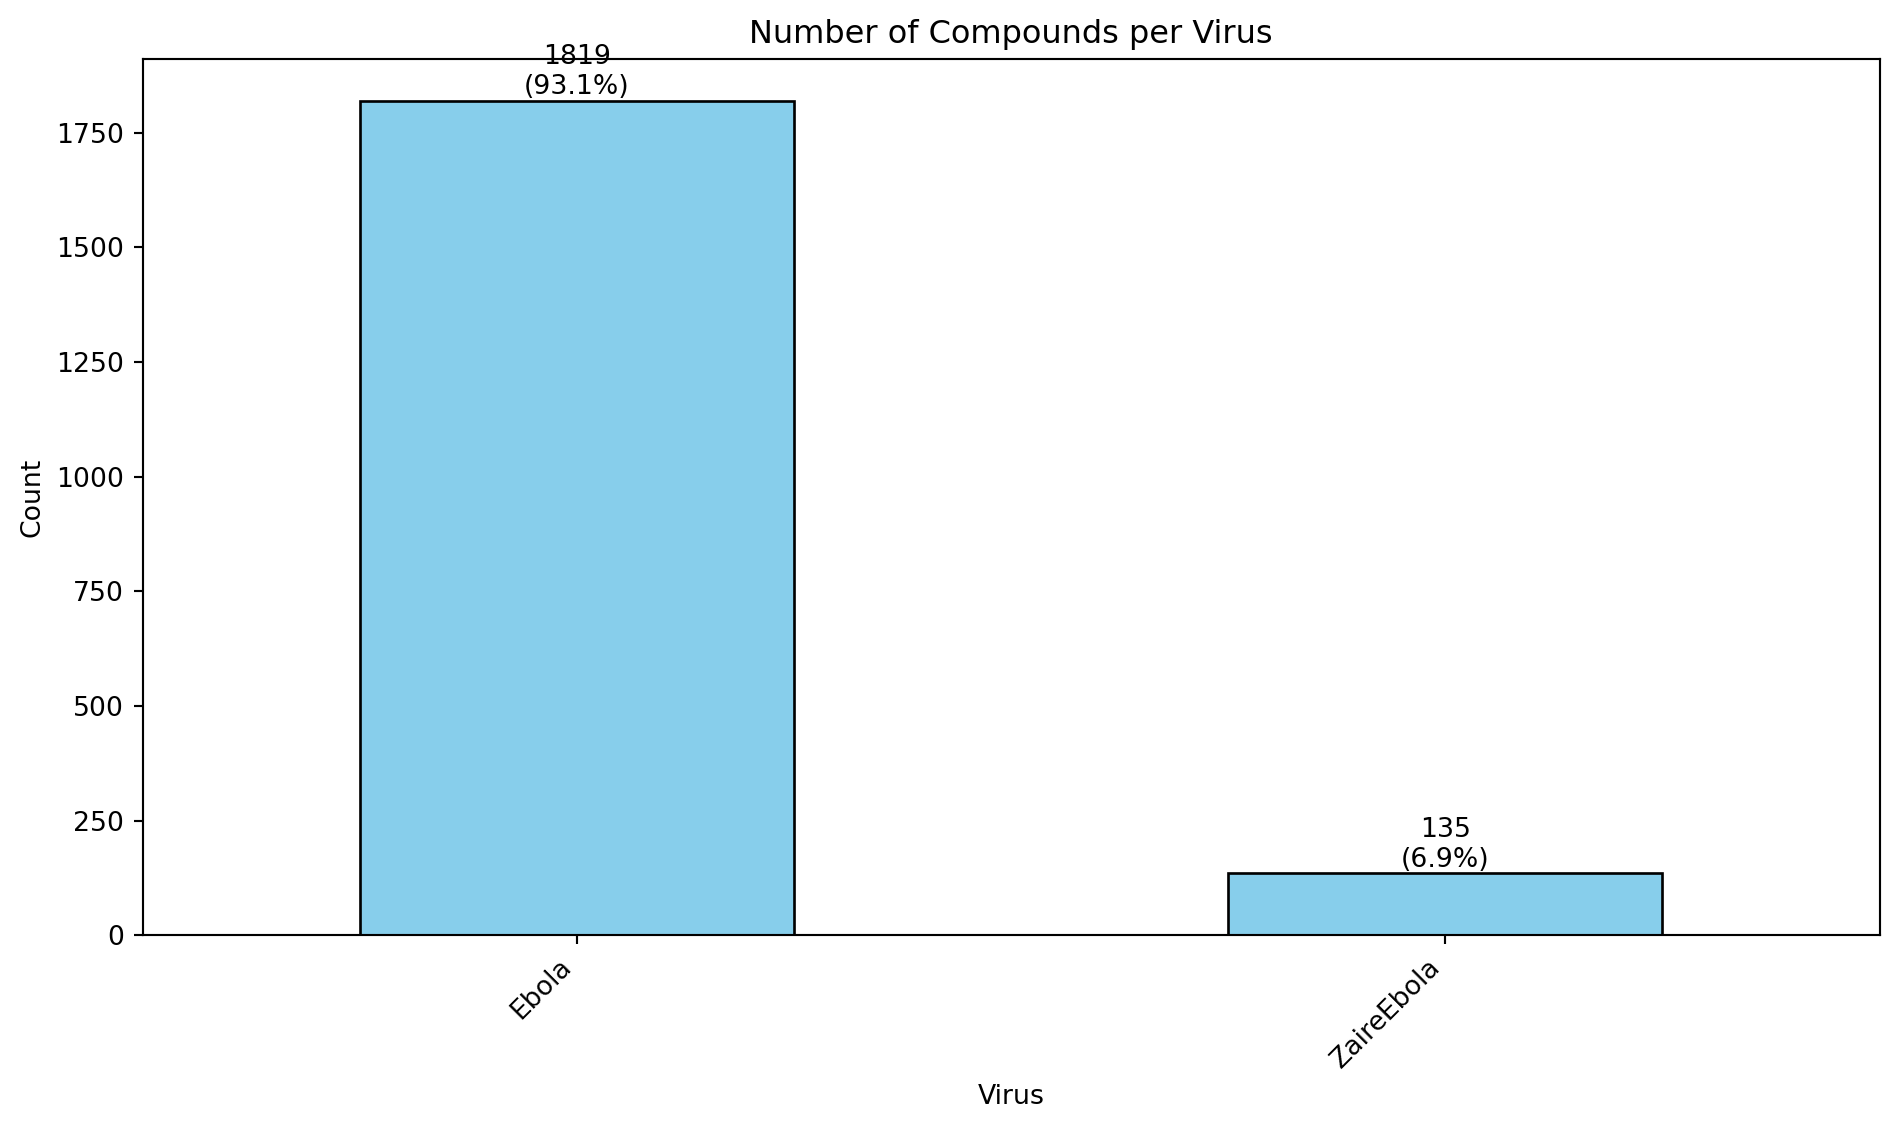

In [31]:
# Get counts and percentages
counts = combinedEbolaVirusData_allDB['StrainClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [32]:
combinedEbolaVirusData_allDB.to_csv(os.path.join(modelBuildingDataDir, "combinedEbolaVirusData_allDB_MLready.csv"), index=False)

### pPotency value distribution across each Virus

In [33]:
combinedEbolaVirusData_allDB_ordered = combinedEbolaVirusData_allDB.sort_values(by='StrainClassifier')
combinedEbolaVirusData_allDB_ordered.head()

,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category
0,1,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,3-10
1222,1223,CHEMBL5596938,COc1cc2c(OCCCN3CCS(=O)(=O)CC3)c3c(c(-c4ccc5c(c...,6.744727,Ebola,3-10
1221,1222,CHEMBL5596273,COc1cc2c(OCCN3CCOCC3)c3c(c(-c4ccc5c(c4)OCO5)c2...,6.186419,Ebola,3-10
1220,1221,CHEMBL4069927,CCOC(=O)[C@H](C)NP(=O)(N[C@@H](C)C(=O)OCC)OC[C...,5.040863,Ebola,3-10
1219,1220,CHEMBL4093434,CCOC(=O)[C@H](C)NP(=O)(OC[C@H]1O[C@@](C#N)(c2c...,6.196543,Ebola,3-10


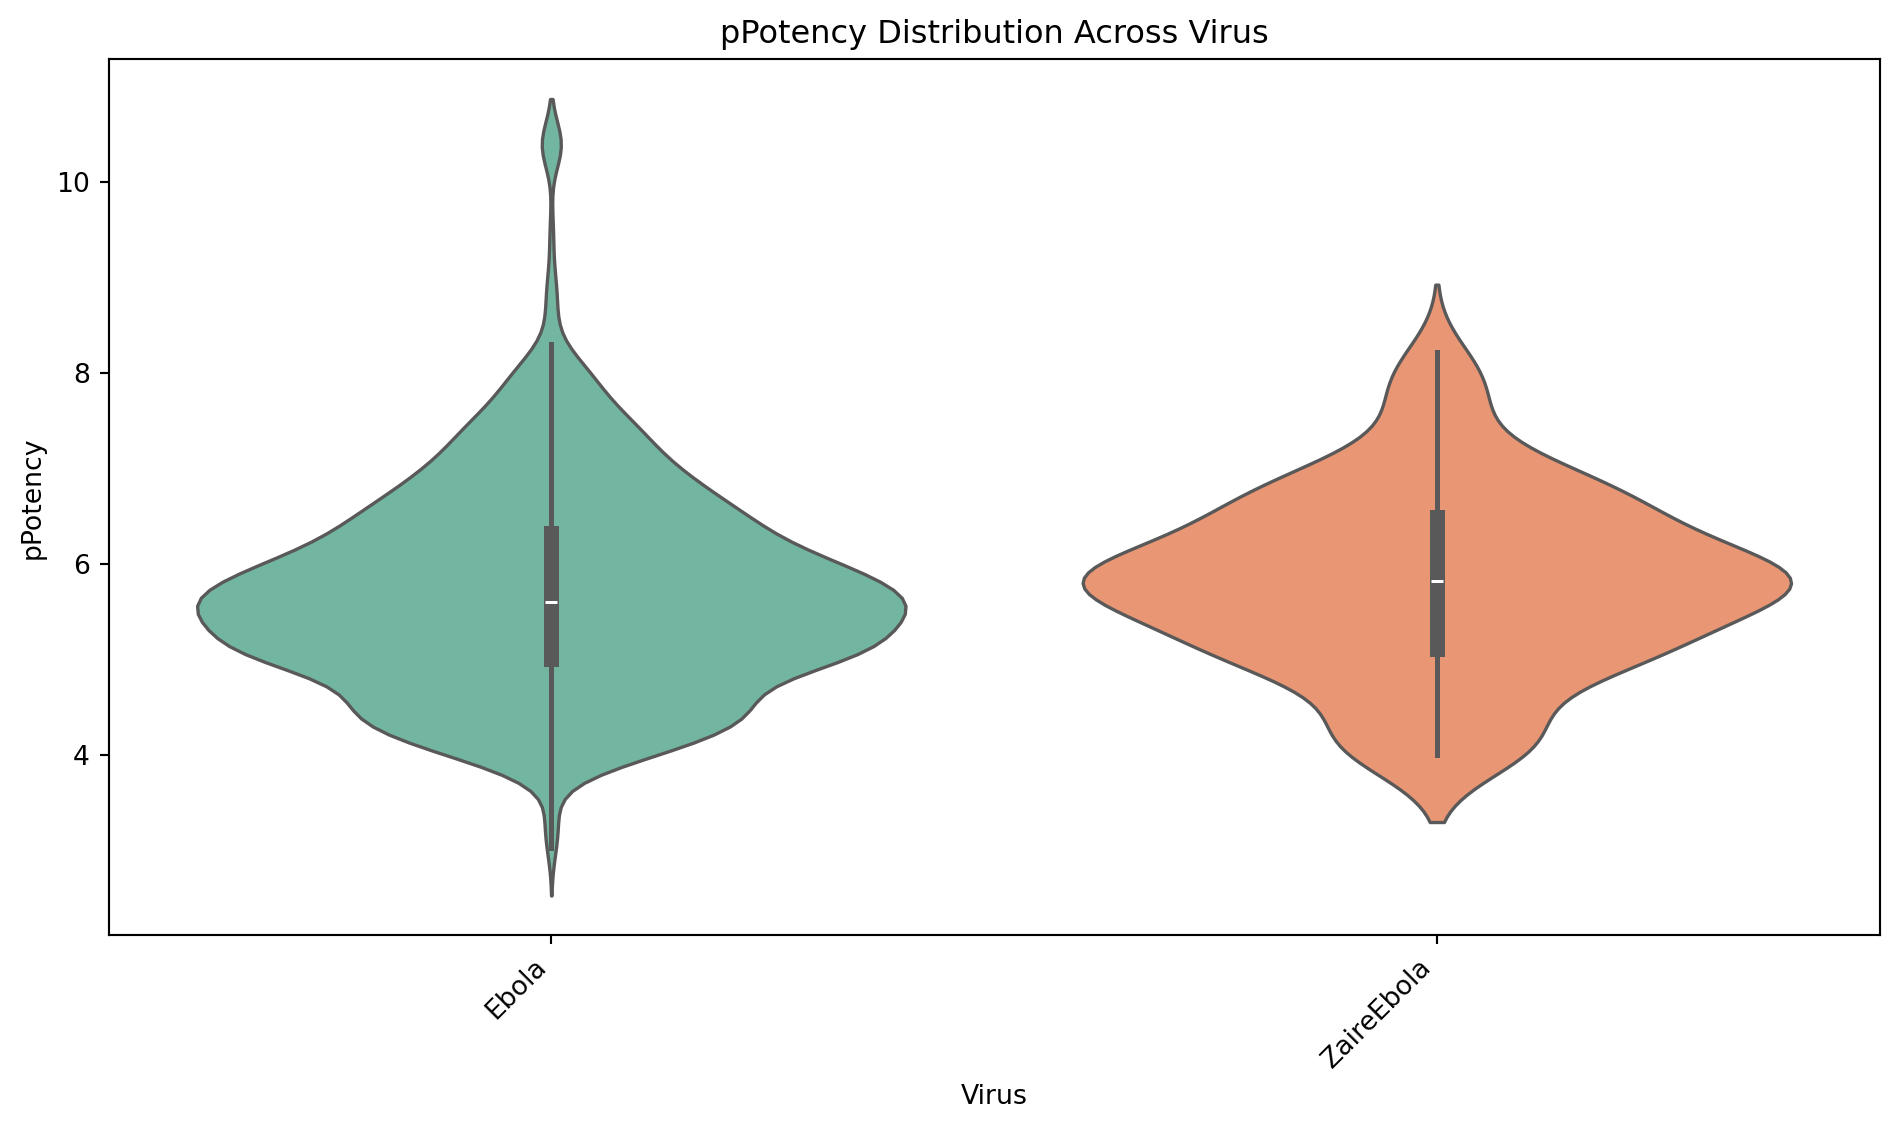

In [34]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=combinedEbolaVirusData_allDB_ordered,
    x='StrainClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

## 2. Find best `MACAW` parameters to train ML Model

In [35]:
Y = combinedEbolaVirusData_allDB.pPotency
smiles = combinedEbolaVirusData_allDB.Smiles

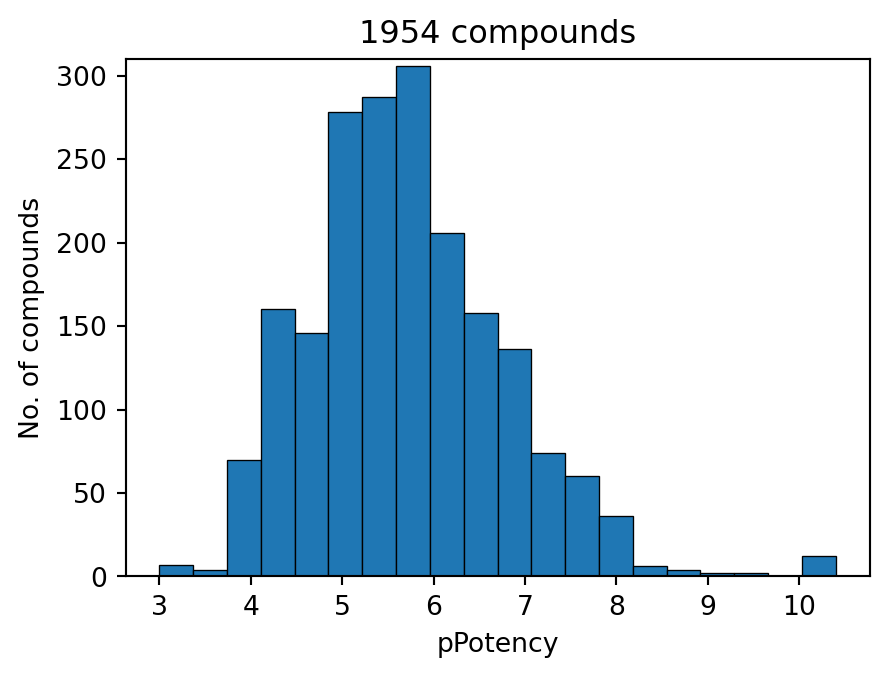

In [36]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [37]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

### 2.1 Define hyperparameters for SVR:

In [38]:
param_grid = {
    "C": [1, 10, 50, 100, 300],
    "gamma": ["scale", 0.01, 0.05, 0.1],
    "epsilon": [0.1, 0.5, 1, 3],
    "kernel": ["rbf"]
}

### 2.2 Find best `MACAW` parameters

In [39]:
nComponentsList = [30, 45, 60, 90]      # set your own parameters
nLandmarksList  = [500, 750, 1000, 1250, 1500] # set own parameters

In [41]:
def processFold(
    foldId, trainIndex, testIndex,
    smiles, Y, baseMacaw, param_grid, numFolds
):
    print(f"Fold {foldId}/{numFolds}")

    smiTrain = smiles.iloc[trainIndex]
    smiTest  = smiles.iloc[testIndex]
    yTrain   = Y.iloc[trainIndex].values
    yTest    = Y.iloc[testIndex].values

    macawFold = deepcopy(baseMacaw)
    macawFold.fit(smiTrain, yTrain)

    XTrain = macawFold.transform(smiTrain)
    XTest  = macawFold.transform(smiTest)

    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(XTrain, yTrain)

    yPredTrain = grid.predict(XTrain)
    yPredTest  = grid.predict(XTest)

    best_params = grid.best_params_
    # Keep the keys in the same order as param_grid
    best_params_ordered = {k: best_params.get(k) for k in param_grid.keys()}
    print("Best SVR parameters:", best_params_ordered)

    return {
        "yObsTrain": yTrain,
        "yPredTrain": yPredTrain,
        "yObsTest": yTest,
        "yPredTest": yPredTest,
        "bestSvrParams": best_params,
        "bestParamsOrdered": best_params_ordered,
    }


# Collect results
macawResultsList = []

# Iterate over MACAW hyperparameters
for nComponents in nComponentsList:
    for nLandmarks in nLandmarksList:

        baseMacaw = MACAW(
            type_fp="atompairs",
            metric="sokal",
            n_components=nComponents,
            n_landmarks=nLandmarks,
            random_state=42
        )

        foldResults = Parallel(n_jobs=16, verbose=10)(
            delayed(processFold)(
                foldId=i + 1,
                trainIndex=trainIdx,
                testIndex=testIdx,
                smiles=smiles,
                Y=Y,
                baseMacaw=baseMacaw,
                param_grid=param_grid,
                numFolds=num_of_partitions,
            )
            for i, (trainIdx, testIdx) in enumerate(kf.split(smiles))
        )

        yObsTrainAll  = np.concatenate([r["yObsTrain"] for r in foldResults])
        yPredTrainAll = np.concatenate([r["yPredTrain"] for r in foldResults])
        yObsTestAll   = np.concatenate([r["yObsTest"] for r in foldResults])
        yPredTestAll  = np.concatenate([r["yPredTest"] for r in foldResults])

        trainR2 = r2_score(yObsTrainAll, yPredTrainAll)
        testR2  = r2_score(yObsTestAll, yPredTestAll)
        gapR2   = trainR2 - testR2  # simple overfit indicator

        macawResultsList.append({
            "n_components": nComponents,
            "n_landmarks": nLandmarks,
            "trainR2": trainR2,
            "testR2": testR2,
            "gapR2": gapR2,
            "testMAE": mean_absolute_error(yObsTestAll, yPredTestAll),
            "testRMSE": np.sqrt(mean_squared_error(yObsTestAll, yPredTestAll)),
        })

        print(
            f"MACAW(n_components={nComponents}, n_landmarks={nLandmarks}) "
            f"=> Test R²={testR2:.3f}, Train R²={trainR2:.3f}, Gap={gapR2:.3f}"
        )

# Build results DataFrame
macawResultsDF = pd.DataFrame(macawResultsList)

# ---- Choose best generalization: max test R² ----
bestGeneralizationRow = macawResultsDF.sort_values("testR2", ascending=False).iloc[0]

best_n_components = int(bestGeneralizationRow["n_components"])
best_n_landmarks  = int(bestGeneralizationRow["n_landmarks"])

print("\nBest MACAW by generalization (highest CV Test R²):")
print("mcw = MACAW(")
print("    type_fp='atompairs', ")
print("    metric='sokal', ")
print(f"    n_components={best_n_components}, ")
print(f"    n_landmarks={best_n_landmarks}, ")
print("    random_state=42")
print(")")

MACAW(n_components=30, n_landmarks=500) => Test R²=0.687, Train R²=0.782, Gap=0.095
MACAW(n_components=30, n_landmarks=750) => Test R²=0.673, Train R²=0.759, Gap=0.086
MACAW(n_components=30, n_landmarks=1000) => Test R²=0.669, Train R²=0.763, Gap=0.094
MACAW(n_components=30, n_landmarks=1250) => Test R²=0.665, Train R²=0.754, Gap=0.089
MACAW(n_components=30, n_landmarks=1500) => Test R²=0.675, Train R²=0.764, Gap=0.089
MACAW(n_components=45, n_landmarks=500) => Test R²=0.694, Train R²=0.801, Gap=0.107
MACAW(n_components=45, n_landmarks=750) => Test R²=0.691, Train R²=0.791, Gap=0.100
MACAW(n_components=45, n_landmarks=1000) => Test R²=0.693, Train R²=0.788, Gap=0.095
MACAW(n_components=45, n_landmarks=1250) => Test R²=0.684, Train R²=0.789, Gap=0.105
MACAW(n_components=45, n_landmarks=1500) => Test R²=0.684, Train R²=0.790, Gap=0.107
MACAW(n_components=60, n_landmarks=500) => Test R²=0.694, Train R²=0.793, Gap=0.099
MACAW(n_components=60, n_landmarks=750) => Test R²=0.684, Train R²=0.7

### 2.3 Run cross validation with best `MACAW` parameters

In [43]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=60, 
    n_landmarks=1000, 
    random_state=42
)

In [44]:
param_grid = {
    'C': [10], 
    'epsilon': [0.1],
    'gamma': ['scale'],
    'kernel': ['rbf']
}

In [45]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 1954 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### 2.4 ML predictions with Train + Test results

In [46]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.28
  RMSE: 0.47
  R²:   0.80
Test Set:
  MAE:  0.37
  RMSE: 0.58
  R²:   0.70
CPU times: user 606 ms, sys: 292 ms, total: 898 ms
Wall time: 17 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_allDB_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_allDB_CV_TrTs.png


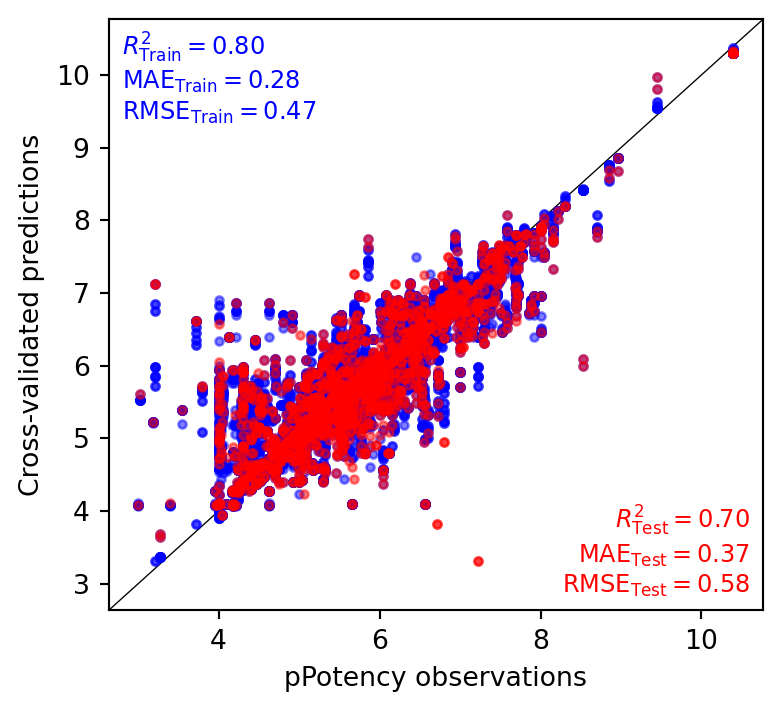

In [47]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + 'combinedEbolaVirus_allDB_CV_TrTs.svg',
            save_formats=['svg', 'png'])

### 2.5 Create `MACAW` embeedings with `best parameters`to run `ART`

In [55]:
# Fit MACAW on SMILES and pPotency
mcw.fit(combinedEbolaVirusData_allDB['Smiles'], combinedEbolaVirusData_allDB['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(saveDir, "combinedEbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(combinedEbolaVirusData_allDB['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=combinedEbolaVirusData_allDB.index)


# Add new MACAW columns to existing data frame 
combinedEbolaVirusData_allDB_wMACAW = pd.concat([combinedEbolaVirusData_allDB, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {combinedEbolaVirusData_allDB.shape}")
print(f"New dataframe shape: {combinedEbolaVirusData_allDB_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
combinedEbolaVirusData_allDB_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (1954, 60)

Original dataframe shape: (1954, 6)
New dataframe shape: (1954, 66)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58

,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category,MACAW_1,MACAW_2,MACAW_3,MACAW_4,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,1,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,3-10,0.237882,-0.055024,0.213845,-0.255485,...,0.004283,0.007330,-0.022609,0.023459,-0.044410,0.006911,0.004934,-0.013307,0.009132,0.055285
1,2,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola,3-10,0.237882,-0.055024,0.213845,-0.255485,...,0.004283,0.007330,-0.022609,0.023459,-0.044410,0.006911,0.004934,-0.013307,0.009132,0.055285
2,3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola,3-10,0.222323,-0.045034,0.171495,-0.234825,...,-0.037945,0.045591,-0.022954,-0.022400,-0.038090,0.040749,-0.006746,-0.013577,0.017598,0.024879
3,4,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola,3-10,0.222323,-0.045034,0.171495,-0.234825,...,-0.037945,0.045591,-0.022954,-0.022400,-0.038090,0.040749,-0.006746,-0.013577,0.017598,0.024879
4,5,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,3-10,0.243881,-0.060614,0.203332,-0.260889,...,-0.020247,0.010476,-0.031571,0.009005,-0.032816,0.018763,-0.014470,0.007396,-0.011788,0.034474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1950,1951,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,3-10,-0.005280,0.001485,-0.110345,-0.036560,...,-0.011219,0.019463,0.025865,-0.030383,-0.038074,-0.008018,-0.055207,0.045639,-0.039768,-0.039618
1951,1952,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,3-10,-0.005280,0.001485,-0.110345,-0.036560,...,-0.011219,0.019463,0.025865,-0.030383,-0.038074,-0.008018,-0.055207,0.045639,-0.039768,-0.039618
1952,1953,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,3-10,0.045672,-0.000983,-0.116051,-0.043644,...,-0.030482,0.039466,0.004131,0.004247,0.085798,0.000191,0.062377,-0.004386,0.012653,0.064275
1953,1954,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,3-10,0.045672,-0.000983,-0.116051,-0.043644,...,-0.030482,0.039466,0.004131,0.004247,0.085798,0.000191,0.062377,-0.004386,0.012653,0.064275


In [56]:
combinedEbolaVirusData_allDB_wMACAW.to_csv(os.path.join(saveDir, "combinedEbolaVirusData_allDB_wMACAW.csv"), index=False)

## 3. Use ART to get predictions using `Ensemble model`

## 4.1 Create a list of data frames of buyable antivirals for external validation: `Enamine, ChemDiv, LifeChemicals`

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [50]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = combinedEbolaVirusData_allDB_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntiviralsData.SMILES
EnamineAntiviralsData['source_DataBase'] = 'Enamine_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
EnamineAntiviralsData = EnamineAntiviralsData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 667
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,source_DataBase
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Enamine_Antivirals
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Enamine_Antivirals
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Enamine_Antivirals
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Enamine_Antivirals
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Enamine_Antivirals


In [51]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntiviralsData = LCAntiviralsData_superset.SMILES
LCAntiviralsData_superset['source_DataBase'] = 'LifeChemicals_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
LCAntiviralsData_superset = LCAntiviralsData_superset[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_LCAntiviralsData)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 667
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,SMILES,source_DataBase
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,LifeChemicals_Antivirals
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,LifeChemicals_Antivirals
2,CN1CCCN(Cc2ccncc2)CC1,LifeChemicals_Antivirals
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,LifeChemicals_Antivirals
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,LifeChemicals_Antivirals


In [52]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiviralsData = ChemDivAntiviralsData.SMILES
ChemDivAntiviralsData['source_DataBase'] = 'ChemDiv_Antivirals'
needed_cols = ['SMILES', 'source_DataBase']
ChemDivAntiviralsData = ChemDivAntiviralsData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiviralsData)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 667
Filtered ChemDiv data shape for validation: (64957, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64957


,SMILES,source_DataBase
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,ChemDiv_Antivirals
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,ChemDiv_Antivirals
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,ChemDiv_Antivirals
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,ChemDiv_Antivirals
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,ChemDiv_Antivirals
...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals


In [53]:
%%time

# Concatenate in chunks and free memory 
DF_list = [
    EnamineAntiviralsData,
    LCAntiviralsData_superset,
    ChemDivAntiviralsData,
]

Ebola_all_Buyable_AntiVirals = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del EnamineAntiviralsData
del LCAntiviralsData_superset
del ChemDivAntiviralsData
gc.collect()

print(f"Total molecules before deduplication: {len(Ebola_all_Buyable_AntiVirals)}")

# Batch canonicalize SMILES using vectorized approach
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
Ebola_all_Buyable_AntiVirals['SMILES'] = canonicalize_smiles_batch(Ebola_all_Buyable_AntiVirals['SMILES'])

# Drop invalid and duplicate SMILES
Ebola_all_Buyable_AntiVirals = Ebola_all_Buyable_AntiVirals.dropna(subset=['SMILES'])
Ebola_all_Buyable_AntiVirals = Ebola_all_Buyable_AntiVirals.drop_duplicates(subset='SMILES', keep='first')
Ebola_all_Buyable_AntiVirals = Ebola_all_Buyable_AntiVirals.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(Ebola_all_Buyable_AntiVirals)}")

# save to a file path string
output_path = saveDir + "Ebola_all_Buyable_AntiVirals.csv"
Ebola_all_Buyable_AntiVirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

Ebola_all_Buyable_AntiVirals

Total molecules before deduplication: 113730
Canonicalizing SMILES...
  Processed 50000/113730 SMILES...
  Processed 100000/113730 SMILES...
  Processed 113730/113730 SMILES...
Total molecules after deduplication: 113185
Saved to /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/Ebola_all_Buyable_AntiVirals.csv
CPU times: user 20 s, sys: 0 ns, total: 20 s
Wall time: 20.1 s


,SMILES,source_DataBase
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals
...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals


### Generate `MACAW` embeedings for all buyable molecules --> to run external validation with `ART`

In [57]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, "combinedEbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Ebola_all_Buyable_AntiVirals['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Ebola_all_Buyable_AntiVirals.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
Ebola_all_Buyable_AntiVirals_wMACAW = pd.concat([Ebola_all_Buyable_AntiVirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Ebola_all_Buyable_AntiVirals.shape}")
print(f"New dataframe shape: {Ebola_all_Buyable_AntiVirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Ebola_all_Buyable_AntiVirals_wMACAW.to_csv(os.path.join(saveDir, "Ebola_all_Buyable_AntiVirals_wMACAW.csv"), index=False)
Ebola_all_Buyable_AntiVirals_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_allDB_MACAW_transformer.joblib
50000
100000
MACAW embeddings shape: (113185, 60)

Original dataframe shape: (113185, 2)
New dataframe shape: (113185, 62)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56',

,SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals,0.163188,0.010665,0.100069,-0.008223,-0.027650,0.004309,0.045641,-0.025008,...,0.002336,0.026218,-0.012065,0.034036,-0.018928,-0.001542,0.006843,-0.007888,0.004028,-0.018840
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals,0.153488,0.039773,0.035338,-0.034237,0.038506,0.006182,0.001180,-0.051615,...,-0.009579,0.065903,-0.016783,0.017391,-0.005033,-0.019989,0.008674,0.037965,-0.021767,-0.016314
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals,0.134157,0.094931,-0.005144,0.010614,-0.058898,-0.077540,-0.037010,-0.034163,...,-0.019402,-0.010920,-0.045763,-0.002688,0.002134,0.018743,-0.032947,-0.041270,-0.007732,0.043300
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals,0.144502,0.091445,0.046280,0.040235,-0.005475,0.004569,-0.004175,-0.053368,...,0.003060,-0.000775,-0.042689,0.015361,-0.040790,-0.006960,0.021390,0.005561,-0.013953,0.025152
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals,0.116260,0.089705,-0.010596,0.002804,0.035979,-0.059483,-0.023975,-0.009068,...,-0.012479,0.006727,-0.055945,0.028399,-0.028961,0.013343,0.030555,0.006383,-0.020247,0.027761


### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
Ebola_all_Buyable_AntiVirals_wARTprediction = pd.read_csv(ARTresultsDir + 'combinedEbolaVirus_wART_EnamineDataset_predicted_all.csv')
max_val = Ebola_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_all_Buyable_AntiVirals_wARTprediction

### Extract `pPotency` predictions

In [ ]:
predicted_pPotency = Ebola_all_Buyable_AntiVirals_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.4f} µM")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
Ebola_all_Buyable_AntiVirals_wARTprediction_top20 = Ebola_all_Buyable_AntiVirals_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
Ebola_all_Buyable_AntiVirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
Ebola_all_Buyable_AntiVirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
Ebola_all_Buyable_AntiVirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.4f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.4f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.4f} - {IC50_min_uM:.4f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.4f}'

# Display the dataframe
Ebola_all_Buyable_AntiVirals_wARTprediction_top20 = Ebola_all_Buyable_AntiVirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_all_Buyable_AntiVirals_wARTprediction_top20

In [ ]:
Ebola_all_Buyable_AntiVirals_wARTprediction_top20.to_csv(os.path.join(saveDir + "Ebola_all_Buyable_AntiVirals_wARTprediction_top20.csv"), index=False)
Ebola_all_Buyable_AntiVirals_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "Ebola_all_Buyable_AntiVirals_wARTprediction_top20_SMILESonly.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_all_Buyable_AntiVirals_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in Ebola_all_Buyable_AntiVirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

In [ ]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_all_Buyable_AntiVirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_all_Buyable_AntiVirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=0,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# Keep only the lookup columns (and drop duplicate SMILES to avoid row explosion)
lookupDF = (
    Ebola_all_Buyable_AntiVirals[["SMILES", "source_DataBase"]]
    .dropna(subset=["SMILES"])
    .drop_duplicates(subset=["SMILES"], keep="first")
)

# Left-merge so every prediction row is preserved; source_DataBase is appended as the last column
Ebola_all_Buyable_AntiVirals_wARTprediction_top20 = Ebola_all_Buyable_AntiVirals_wARTprediction_top20.merge(
    lookupDF,
    how="left",
    on="SMILES",
    validate="many_to_one"  # many predictions can map to one SMILES in lookup
)

Ebola_all_Buyable_AntiVirals_wARTprediction_top20

# 4.2 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

### Import all compounds generated by `DORAnet` from `Inosine` only (gen=3) --> Possible `Antivirals`

In [58]:
InosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "InosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(InosineOnly_DORAnetGenerated)} molecules")
InosineOnly_DORAnetGenerated

Loaded 4728 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,True,InosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3
...,...,...,...
4723,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H](...,False,InosineOnly_gen3
4724,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,False,InosineOnly_gen3
4725,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,False,InosineOnly_gen3
4726,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H...,False,InosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Adenosine` only (gen=3) --> Possible `Antivirals`

In [59]:
AdenosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "AdenosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(AdenosineOnly_DORAnetGenerated)} molecules")
AdenosineOnly_DORAnetGenerated['SourceDirectories'] = 'AdenosineOnly_gen3'
AdenosineOnly_DORAnetGenerated

Loaded 5283 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H...,True,AdenosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,AdenosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,AdenosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,AdenosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,AdenosineOnly_gen3
...,...,...,...
5278,Nc1nc2nc3c1ncn3[C@@H]1O[C@H](C(N)O)[C@@H](O)[C...,False,AdenosineOnly_gen3
5279,O=C1Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,False,AdenosineOnly_gen3
5280,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(N)O)[C@@H](O)[C@...,False,AdenosineOnly_gen3
5281,CNC(=O)[C@H]1O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)...,False,AdenosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Guanosine` only (gen=3) --> Possible `Antivirals`

In [60]:
GuanosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "GuanosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(GuanosineOnly_DORAnetGenerated)} molecules")
GuanosineOnly_DORAnetGenerated

Loaded 6186 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O...,True,GuanosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,GuanosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,GuanosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,GuanosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,GuanosineOnly_gen3
...,...,...,...
6181,Nc1nc2c(ncn2[C@@H]2O[C@H](C(N)O)[C@@H](O)[C@H]...,False,GuanosineOnly_gen3
6182,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C...,False,GuanosineOnly_gen3
6183,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C...,False,GuanosineOnly_gen3
6184,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[...,False,GuanosineOnly_gen3


### Import all compounds generated by `DORAnet` from `Xanthosine` only (gen=3) --> Possible `Antivirals`

In [61]:
XanthosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "XanthosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(XanthosineOnly_DORAnetGenerated)} molecules")
XanthosineOnly_DORAnetGenerated

Loaded 4355 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O...,True,XanthosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,XanthosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,XanthosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,XanthosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,XanthosineOnly_gen3
...,...,...,...
4350,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3
4351,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3
4352,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3
4353,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3


### Marge the data for all `DORAnet` generated `Antivirals` for different starter molecule

In [62]:
%%time

# Concatenate in chunks and free memory ---
DF_list = [
    InosineOnly_DORAnetGenerated,
    AdenosineOnly_DORAnetGenerated,
    GuanosineOnly_DORAnetGenerated,
    XanthosineOnly_DORAnetGenerated,
]

Ebola_allDORAnetGenerated_Antivirals = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del InosineOnly_DORAnetGenerated
del AdenosineOnly_DORAnetGenerated
del GuanosineOnly_DORAnetGenerated
del XanthosineOnly_DORAnetGenerated
gc.collect()

print(f"Total molecules before deduplication: {len(Ebola_allDORAnetGenerated_Antivirals)}")

# --- 2. Only keep needed columns early ---
#needed_cols = ['SMILES', 'Is_Starter', 'SourceDirectories', 'source_DataBase']
#Ebola_allDORAnetGenerated_Antivirals = Ebola_allDORAnetGenerated_Antivirals[needed_cols]

# --- 3. Batch canonicalize SMILES using vectorized approach ---
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
Ebola_allDORAnetGenerated_Antivirals['SMILES'] = canonicalize_smiles_batch(Ebola_allDORAnetGenerated_Antivirals['SMILES'])

# --- 4. Drop invalid and duplicate SMILES ---
Ebola_allDORAnetGenerated_Antivirals = Ebola_allDORAnetGenerated_Antivirals.dropna(subset=['SMILES'])
Ebola_allDORAnetGenerated_Antivirals = Ebola_allDORAnetGenerated_Antivirals.drop_duplicates(subset='SMILES', keep='first')
Ebola_allDORAnetGenerated_Antivirals = Ebola_allDORAnetGenerated_Antivirals.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(Ebola_allDORAnetGenerated_Antivirals)}")

# --- 5. Fix: save to a file path string, not the dataframe variable ---
output_path = DORANETmoleculesDataDir + "Ebola_allDORAnetGenerated_Antivirals.csv"
Ebola_allDORAnetGenerated_Antivirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

Ebola_allDORAnetGenerated_Antivirals

Total molecules before deduplication: 20552
Canonicalizing SMILES...
  Processed 20552/20552 SMILES...
Total molecules after deduplication: 20372
Saved to /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/DORAnet_molecules/Ebola_allDORAnetGenerated_Antivirals.csv
CPU times: user 3.19 s, sys: 0 ns, total: 3.19 s
Wall time: 3.35 s


,SMILES,Is_Starter,SourceDirectories
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3
...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3


### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [63]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, "combinedEbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(Ebola_allDORAnetGenerated_Antivirals['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=Ebola_allDORAnetGenerated_Antivirals.index)
Ebola_allDORAnetGenerated_Antivirals_wMACAW = pd.concat([Ebola_allDORAnetGenerated_Antivirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {Ebola_allDORAnetGenerated_Antivirals.shape}")
print(f"New dataframe shape: {Ebola_allDORAnetGenerated_Antivirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
Ebola_allDORAnetGenerated_Antivirals_wMACAW.to_csv(os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_wMACAW.csv"), index=False)
Ebola_allDORAnetGenerated_Antivirals_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (20372, 60)

Original dataframe shape: (20372, 3)
New dataframe shape: (20372, 63)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MA

,SMILES,Is_Starter,SourceDirectories,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,0.198556,-0.038594,0.196612,-0.191335,-0.051828,0.135890,-0.134896,...,0.057510,0.008632,-0.000814,0.035407,-0.048322,-0.014627,-0.016158,-0.007848,-0.009703,0.034153
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,0.034152,-0.071527,0.164790,-0.072358,0.017499,0.014963,-0.055491,...,0.034385,-0.013572,-0.010744,-0.011032,-0.026339,0.015227,0.002475,0.005588,-0.032115,0.002364
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,0.140310,-0.052569,0.186787,-0.155597,-0.023353,0.078480,-0.109581,...,0.027393,-0.027603,-0.012267,0.015189,-0.035375,-0.009253,0.013985,0.013028,0.005221,0.029229
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,-0.144934,-0.080400,0.173883,-0.004967,0.022418,-0.058935,-0.002376,...,0.016294,-0.003244,0.002187,0.013559,0.011383,0.002003,-0.004000,0.012689,0.001641,-0.007204
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,-0.155930,-0.075359,0.164917,-0.003582,0.017690,-0.063040,-0.002396,...,0.017553,-0.011901,0.000954,0.011055,0.007963,-0.006276,-0.002336,0.008001,0.006370,0.002023


## Read results (`SMILES` & `pPotency`) from `ART` post predictions with uncertentity

In [ ]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')
max_val = Ebola_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_allDORAnetGenerated_Antivirals_wARTprediction

In [ ]:
def get_top20_range(df, group_name):
    top20 = df.nlargest(20, 'pPotency_prediction')
    best = top20.iloc[0]
    cutoff = top20.iloc[-1]
    return {
        'SourceDirectories': group_name,
        'Total Molecules': len(df),
        'pPotency Range': f"{cutoff['pPotency_prediction']:.3f} ± {cutoff['pPotency_std']:.3f} – {best['pPotency_prediction']:.3f} ± {best['pPotency_std']:.3f}",
        'IC50 (µM)': f"{best['IC50(M)_prediction'] * 1e6:.4f} – {cutoff['IC50(M)_prediction'] * 1e6:.4f}",
    }

rows = [get_top20_range(Ebola_allDORAnetGenerated_Antivirals_wARTprediction, "all Molecules")]

for source in sorted(Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'].unique()):
    subset = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
        Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == source
    ]
    rows.append(get_top20_range(subset, source))

Ebola_allDORAnetGenerated_Antivirals_wARTprediction_summary = pd.DataFrame(rows)
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_summary

### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [ ]:
predicted_pPotency = Ebola_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_allDORAnetGenerated_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = Ebola_allDORAnetGenerated_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20 = Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Inosine` only `DORAnet` run

In [ ]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Ebola_InosineOnly_Antivirals_wARTprediction = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
    Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'InosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Ebola_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Inosine only: {len(Ebola_InosineOnly_Antivirals_wARTprediction)}")

max_val = Ebola_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_InosineOnly_Antivirals_wARTprediction

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
predicted_pPotency = Ebola_InosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_InosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Ebola_InosineOnly_Antivirals_wARTprediction_top20 = Ebola_InosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_InosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_InosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_InosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_InosineOnly_Antivirals_wARTprediction_top20 = Ebola_InosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_InosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_InosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_InosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_InosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_InosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_InosineOnly_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_InosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_InosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_InosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_InosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_InosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Adenosine` only `DORAnet` run

In [ ]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Ebola_AdenosineOnly_Antivirals_wARTprediction = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
    Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'AdenosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Ebola_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Adenosine only: {len(Ebola_AdenosineOnly_Antivirals_wARTprediction)}")

max_val = Ebola_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_AdenosineOnly_Antivirals_wARTprediction

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
predicted_pPotency = Ebola_AdenosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_AdenosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20 = Ebola_AdenosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_AdenosineOnly_Antivirals_wARTprediction_top20 = Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_AdenosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_AdenosineOnly_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_AdenosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_AdenosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_AdenosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_AdenosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Guanosine` only `DORAnet` run

In [ ]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Ebola_GuanosineOnly_Antivirals_wARTprediction = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
    Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'GuanosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Ebola_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Guanosine only: {len(Ebola_GuanosineOnly_Antivirals_wARTprediction)}")

max_val = Ebola_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_GuanosineOnly_Antivirals_wARTprediction

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
predicted_pPotency = Ebola_GuanosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_GuanosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20 = Ebola_GuanosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_GuanosineOnly_Antivirals_wARTprediction_top20 = Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_GuanosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_GuanosineOnly_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_GuanosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_GuanosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_GuanosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_GuanosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## Top20 potent compound generated from `Xanthosine` only `DORAnet` run

In [ ]:
Ebola_allDORAnetGenerated_Antivirals_wARTprediction = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')

Ebola_XanthosineOnly_Antivirals_wARTprediction = Ebola_allDORAnetGenerated_Antivirals_wARTprediction[
    Ebola_allDORAnetGenerated_Antivirals_wARTprediction['SourceDirectories'] == 'XanthosineOnly_gen3'].reset_index(drop=True)

print(f"Total molecules: {len(Ebola_allDORAnetGenerated_Antivirals_wARTprediction)}")
print(f"DORAnet molecules generated by Xanthosine only: {len(Ebola_XanthosineOnly_Antivirals_wARTprediction)}")

max_val = Ebola_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].max()
min_val = Ebola_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_XanthosineOnly_Antivirals_wARTprediction

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
predicted_pPotency = Ebola_XanthosineOnly_Antivirals_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = Ebola_XanthosineOnly_Antivirals_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20 = Ebola_XanthosineOnly_Antivirals_wARTprediction.iloc[top_20_idx].copy()
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

Ebola_XanthosineOnly_Antivirals_wARTprediction_top20 = Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20

output_csv = os.path.join(saveDir, "Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_SMILESonly.csv")
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.to_csv(output_csv, index=False)
Ebola_XanthosineOnly_Antivirals_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

Ebola_XanthosineOnly_Antivirals_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_XanthosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in Ebola_XanthosineOnly_Antivirals_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in Ebola_XanthosineOnly_Antivirals_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'Ebola_XanthosineOnly_Antivirals_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## 4.3 Import all `Inosine Substructures` compounds generated by `DORAnet` --> Possible `Antivirals`

In [64]:
InosineSubstructures_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "InosineSubstructures_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(InosineSubstructures_DORAnetGenerated)} molecules")
InosineSubstructures_DORAnetGenerated['source_DataBase'] = 'Inosine_Substructures'
InosineSubstructures_DORAnetGenerated

Loaded 20880 molecules


,SMILES,Is_Starter,SourceDirectories,source_DataBase
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures
...,...,...,...,...
20875,O=C1Oc2nc3c(c(=O)[nH]2)n1c[n+]3[C@@H]1O[C@H](C...,False,starter_00352,Inosine_Substructures
20876,O=C(O)n1c[n+]([C@@H]2O[C@H](C(O)O)[C@@H](O)[C@...,False,starter_00352,Inosine_Substructures
20877,N#CC(O)(O)[C@H]1O[C@@H]([n+]2cn(C(=O)O)c3c(=O)...,False,starter_00352,Inosine_Substructures
20878,NC(=O)[C@H]1O[C@@H]([n+]2cn(C(=O)O)c3c(=O)[nH]...,False,starter_00352,Inosine_Substructures


### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [65]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, "combinedEbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(InosineSubstructures_DORAnetGenerated['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=InosineSubstructures_DORAnetGenerated.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
InosineSubstructures_DORAnetGenerated_wMACAW = pd.concat([InosineSubstructures_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {InosineSubstructures_DORAnetGenerated.shape}")
print(f"New dataframe shape: {InosineSubstructures_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
InosineSubstructures_DORAnetGenerated_wMACAW.to_csv(os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.csv"), index=False)
InosineSubstructures_DORAnetGenerated_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (20880, 60)

Original dataframe shape: (20880, 4)
New dataframe shape: (20880, 64)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MA

,SMILES,Is_Starter,SourceDirectories,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,0.034152,-0.071527,0.164790,-0.072358,0.017499,0.014963,...,0.034385,-0.013572,-0.010744,-0.011032,-0.026339,0.015227,0.002475,0.005588,-0.032115,0.002364
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,0.140310,-0.052569,0.186787,-0.155597,-0.023353,0.078480,...,0.027393,-0.027603,-0.012267,0.015189,-0.035375,-0.009253,0.013985,0.013028,0.005221,0.029229
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,-0.144934,-0.080400,0.173883,-0.004967,0.022418,-0.058935,...,0.016294,-0.003244,0.002187,0.013559,0.011383,0.002003,-0.004000,0.012689,0.001641,-0.007204
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,-0.155930,-0.075359,0.164917,-0.003582,0.017690,-0.063040,...,0.017553,-0.011901,0.000954,0.011055,0.007963,-0.006276,-0.002336,0.008001,0.006370,0.002023
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,Inosine_Substructures,0.076764,-0.068153,0.164824,-0.113838,0.003792,0.057865,...,0.020606,-0.017132,-0.005726,0.016628,-0.031903,0.012964,0.015103,-0.008449,-0.021800,0.007404


### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction = pd.read_csv(ARTresultsDir + 'combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.csv')
max_val = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].max()
min_val = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction

### Extract `pPotency` predictions

In [ ]:
predicted_pPotency = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20 = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.4f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.4f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.4f} - {IC50_min_uM:.4f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.4f}'

# Display the dataframe
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20 = InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20

In [ ]:
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.to_csv(os.path.join(saveDir + "InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.csv"), index=False)
InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_SMILESonly.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

In [ ]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'InosineSimilarstructures_DORAnetGeneratedMolecules_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=2,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

## 4.4 Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [71]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [72]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_Antiviral_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_Antiviral_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_Antiviral_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol
 Molnupiravir
  Formula: C13H19N3O7
  MW: 329.31 g/mol
Total DTRA target compounds to screen: 2


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.59
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.31


### Generate `MACAW` embeedings for `DORAnet` generated molecules --> to run external validation with `ART`

In [73]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(saveDir, "combinedEbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(DTRA_target_Antiviral_SMILES['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=DTRA_target_Antiviral_SMILES.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
DTRA_target_Antiviral_SMILES_wMACAW = pd.concat([DTRA_target_Antiviral_SMILES, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {DTRA_target_Antiviral_SMILES.shape}")
print(f"New dataframe shape: {DTRA_target_Antiviral_SMILES_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
DTRA_target_Antiviral_SMILES_wMACAW.to_csv(os.path.join(saveDir, "combinedEbolaVirusData_DTRA_target_Antiviral_SMILES_wMACAW.csv"), index=False)
DTRA_target_Antiviral_SMILES_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirusData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (2, 60)

Original dataframe shape: (2, 4)
New dataframe shape: (2, 64)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MA

,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.59,-0.211091,-0.164819,0.338714,-0.026474,0.115983,-0.181729,...,-0.000012,-0.004654,-0.020814,-0.050107,0.040863,-0.012432,-0.033618,0.013280,-0.008476,-0.003786
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.31,0.106048,-0.046744,0.175127,-0.069323,0.017728,0.052945,...,-0.032602,0.022668,-0.018894,0.023465,0.000765,0.028447,0.004308,0.013922,-0.030133,0.011030


### Import ART predictions

In [ ]:
DTRA_target_Antiviral_SMILES_predicted = pd.read_csv(saveDir + 'combinedEbolaVirus_wART_DTRA_target_antivirals_predicted_all.csv')
max_val = DTRA_target_Antiviral_SMILES_predicted['pPotency_prediction'].max()
min_val = DTRA_target_Antiviral_SMILES_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

def canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

DTRA_target_Antiviral_SMILES['can_smiles'] = DTRA_target_Antiviral_SMILES['SMILES'].apply(canonical)
DTRA_target_Antiviral_SMILES_predicted['can_smiles'] = DTRA_target_Antiviral_SMILES_predicted['SMILES'].apply(canonical)

DTRA_target_Antiviral_SMILES_predicted = DTRA_target_Antiviral_SMILES_predicted.merge(
    DTRA_target_Antiviral_SMILES[['can_smiles', 'Drug_Name']],
    on='can_smiles',
    how='left')

cols = ['Drug_Name'] + [c for c in DTRA_target_Antiviral_SMILES_predicted.columns if c != 'Drug_Name']
DTRA_target_Antiviral_SMILES_predicted = DTRA_target_Antiviral_SMILES_predicted[cols]
DTRA_target_Antiviral_SMILES_predicted = DTRA_target_Antiviral_SMILES_predicted.drop(columns=['can_smiles'])
DTRA_target_Antiviral_SMILES_predicted

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in DTRA_target_Antiviral_SMILES_predicted.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in DTRA_target_Antiviral_SMILES_predicted[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'combinedEbolaVirus_DTRA_target_antivirals_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'combinedEbolaVirus_DTRA_target_antivirals_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  